# Train Naive Bayes Sentiment Model

This notebook loads the provided Excel datasets, trains a Multinomial Naive Bayes classifier for sentiment, evaluates it with a confusion matrix, and saves `model.joblib` and `vectorizer.joblib` in this folder. It also includes a small FastAPI app example to serve predictions.

Files expected at the workspace root: `CivicPulse_Train.xlsx`, `CivicPulse_Test.xlsx`. If column names differ, update the `text_col` and `label_col` variables in the cell that prepares the data.

In [1]:
# Imports
import os
import pandas as pd
import joblib
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('Imports ok')

Imports ok


In [2]:
# Paths (notebook is in ml-service/)
train_path = os.path.join('..', 'CivicPulse_Train.xlsx')
test_path = os.path.join('..', 'CivicPulse_Test.xlsx')

print('Train path:', train_path)
print('Test path:', test_path)

train_df = pd.read_excel(train_path)
test_df = pd.read_excel(test_path)

print('Train columns:', train_df.columns.tolist())
print('Test columns:', test_df.columns.tolist())

Train path: ..\CivicPulse_Train.xlsx
Test path: ..\CivicPulse_Test.xlsx
Train columns: ['Complaint_ID', 'Area', 'City_or_District', 'MLA', 'Corporator', 'Category', 'Complaint_Text', 'Sentiment_Label', 'Population', 'Timestamp']
Test columns: ['Complaint_ID', 'Area', 'City_or_District', 'MLA', 'Corporator', 'Category', 'Complaint_Text', 'Sentiment_Label', 'Population', 'Timestamp']


In [3]:
# Guess common column names for text and label then allow easy override
def guess_columns(df):
    text_col = None
    label_col = None
    for c in df.columns:
        cl = c.lower()
        if any(k in cl for k in ['text','complaint','comment','message','body']):
            text_col = c
        if any(k in cl for k in ['label','sentiment','target','class']):
            label_col = c
    return text_col, label_col

text_col, label_col = guess_columns(train_df)
print('Auto-detected text column:', text_col)
print('Auto-detected label column:', label_col)

# If detection failed, set below explicitly (edit these lines if needed)
if text_col is None:
    text_col = train_df.columns[0]  # fallback to first column
if label_col is None:
    label_col = train_df.columns[-1]  # fallback to last column

print('Using text column:', text_col)
print('Using label column:', label_col)

# Prepare X and y
X = train_df[text_col].astype(str).fillna('')
y = train_df[label_col]

# Normalize textual label values if present
if y.dtype == object or y.dtype.name == 'category':
    y = y.astype(str).str.lower()
    mapping = {'positive':1,'pos':1,'p':1,'negative':0,'neg':0,'n':0}
    y = y.map(mapping).fillna(y)

# Attempt to cast to int if possible
try:
    y = y.astype(int)
except Exception:
    print('Labels could not be cast to ints; please inspect y values')

print('Value counts for labels:', y.value_counts(dropna=False))

Auto-detected text column: Complaint_Text
Auto-detected label column: Sentiment_Label
Using text column: Complaint_Text
Using label column: Sentiment_Label
Labels could not be cast to ints; please inspect y values
Value counts for labels: Sentiment_Label
Negative    390
Neutral     165
Positive    145
Name: count, dtype: int64


In [4]:
# Split, vectorize, and train
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if len(pd.unique(y))>1 else None)
vect = CountVectorizer(stop_words='english', ngram_range=(1,2), max_features=20000)
Xtr = vect.fit_transform(X_train)
Xv = vect.transform(X_val)
model = MultinomialNB()
model.fit(Xtr, y_train)

pred = model.predict(Xv)
acc = accuracy_score(y_val, pred)
print(f'Validation accuracy: {acc:.4f}')
print('Classification report:')
print(classification_report(y_val, pred))

Validation accuracy: 1.0000
Classification report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        78
     Neutral       1.00      1.00      1.00        33
    Positive       1.00      1.00      1.00        29

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



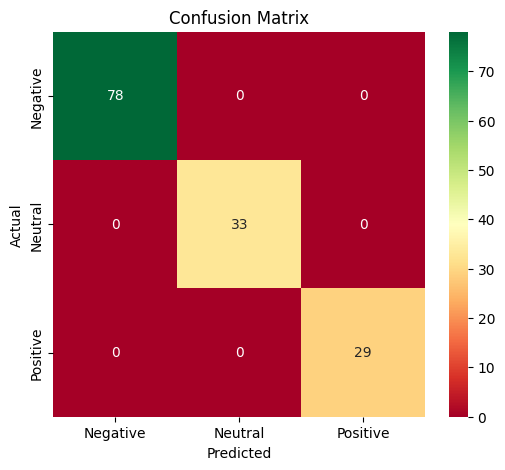

In [5]:
# Confusion matrix visualization
cm = confusion_matrix(y_val, pred)
labels = sorted(list(pd.unique(y_val)))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [6]:
# Optionally evaluate on provided test file if it has same columns
try:
    if text_col in test_df.columns and label_col in test_df.columns:
        X_test = test_df[text_col].astype(str).fillna('')
        y_test = test_df[label_col]
        if y_test.dtype == object or y_test.dtype.name == 'category':
            y_test = y_test.astype(str).str.lower().map({'positive':1,'pos':1,'negative':0,'neg':0}).fillna(y_test)
        try:
            y_test = y_test.astype(int)
        except Exception:
            pass
        Xt = vect.transform(X_test)
        tpred = model.predict(Xt)
        print('Test accuracy:', accuracy_score(y_test, tpred))
        print(classification_report(y_test, tpred))
except Exception as e:
    print('Could not evaluate on test set:', e)

Test accuracy: 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       169
     Neutral       1.00      1.00      1.00        65
    Positive       1.00      1.00      1.00        66

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [7]:
# Save artifacts for FastAPI service
joblib.dump(model, 'model.joblib')
joblib.dump(vect, 'vectorizer.joblib')
print('Saved model.joblib and vectorizer.joblib in current folder')

Saved model.joblib and vectorizer.joblib in current folder


In [8]:
# FastAPI app (app/main.py). Run from terminal with: uvicorn app.main:app --reload --port 8001
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import os

class Item(BaseModel):
    text: str

def create_app(model_path='model.joblib', vect_path='vectorizer.joblib'):
    app = FastAPI()
    model = joblib.load(model_path)
    vect = joblib.load(vect_path)

    @app.post('/predict')
    def predict(item: Item):
        X = vect.transform([item.text])
        pred = model.predict(X)[0]
        proba = model.predict_proba(X)[0].tolist() if hasattr(model, 'predict_proba') else None
        return {'prediction': int(pred), 'probability': proba}

    return app

# Create and display app
app = create_app()
print('✓ FastAPI app created successfully!')
print('To run the service from terminal, use:')
print('  cd ml-service')
print('  uvicorn app.main:app --reload --port 8001')
print('Then visit: http://localhost:8001/docs for interactive API docs')


✓ FastAPI app created successfully!
To run the service from terminal, use:
  cd ml-service
  uvicorn app.main:app --reload --port 8001
Then visit: http://localhost:8001/docs for interactive API docs
